<div dir="rtl" style="text-align:right">
<h1 id="פרק-0-דוגמאות-python">פרק 0 — דוגמאות Python</h1>
<p dir="rtl" style="text-align:right">זו מחברת Python 3 הנלווית למחברת ההרצאה המלאה ב-Julia. נריץ לפי הסדר. טבלת הנפילה החופשית שלהלן היא נתוני הדגמה מסופקים במפורש; דוגמת גלי הכבידה קוראת מדידות ציבוריות אמיתיות.</p>
<p dir="rtl" style="text-align:right"><a href="lecture-he.ipynb">Complete lecture</a></p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">שורת ההכנה הראשונה מאפשרת הצגת איורים בתוך Jupyter. בהרצה הראשונה נוריד קבצים רשמיים משני אתרי LIGO; הרצות נוספות ישתמשו במטמון ההורדות של GWpy. נאפשר עד 90 שניות לקריאה איטית מהרשת. ההגדרות אינן משנות את הנתונים או את המסננים. אפשר לקרוא פלט שמור ללא רשת; חיפוש האירוע והורדה שאינה במטמון דורשים חיבור.</p>
</div>

In [1]:
%matplotlib inline
import matplotlib
# Explicit module name keeps GWpy compatible with the inline backend.
matplotlib.use("module://matplotlib_inline.backend_inline")
import os
os.environ["GWPY_CACHE"] = "1"
from astropy.utils.data import conf
conf.remote_timeout = 90.0

<div dir="rtl" style="text-align:right">
<h2 id="נתוני-הדגמה-להצצה-לניתוח-נתונים">נתוני הדגמה להצצה לניתוח נתונים</h2>
<p dir="rtl" style="text-align:right">הפרק מדגים הסרת שורה חסרה והתאמת מיקום לריבוע הזמן בלי להגדיר את <code dir="ltr">data</code> ואת <code dir="ltr">np</code>. נספק טבלת נפילה אידיאלית ממנוחה: זמן בשניות ומרחק חיובי מטה במטרים, עם g = 9.81 מטר לשנייה בריבוע וזמן חסר אחד. אלה אינם נתוני גלי כבידה.</p>
</div>

In [2]:
import numpy as np
import pandas as pd
data = pd.DataFrame({"time_s": [0.0, 1.0, 2.0, 3.0, np.nan],
                     "position_m": [0.0, 4.905, 19.62, 44.145, 99.0]})
data

,time_s,position_m
0,0.0,0.000
1,1.0,4.905
2,2.0,19.620
3,3.0,44.145
4,NaN,99.000


In [3]:
clean = data.dropna(subset=["time_s", "position_m"])
clean["time_squared"] = clean["time_s"] ** 2
fit = np.polyfit(clean["time_squared"], clean["position_m"], 1)
gravity = 2 * fit[0]

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">נתוני ההדגמה האידיאליים אמורים להחזיר 9.81 מטר לשנייה בריבוע.</p>
</div>

In [4]:
gravity

np.float64(9.810000000000004)

<div dir="rtl" style="text-align:right">
<h2 id="gw150914-בשני-אתרי-ligo">GW150914 בשני אתרי LIGO</h2>
<p dir="rtl" style="text-align:right">נוריד 32 שניות מהאנפורד ומליווינגסטון, נפעיל אותו מסנן מעביר-פס של 50–250 הרץ ומסנני חריץ ב-60/120/180 הרץ, ונשווה את 0.6 השניות המרכזיות. סדרת ליווינגסטון מוזזת קדימה ב-6.9 מילישניות, הפרש ההגעה שדווח, ומוכפלת ב-‎-1 בגלל כיווני הגלאים. הדוגמה מבוססת על <a href="https://gwpy.github.io/docs/3.0.7/examples/signal/gw150914/">דוגמת GW150914 של GWpy</a>. נתונים שאינם במטמון דורשים רשת. המעוות חסר ממד; סינון והתאמה חזותית אינם לבדם מבחן גילוי. מקור: <a href="https://gwosc.org/GW150914/">GWOSC</a>, ברישיון CC BY 4.0.</p>
</div>

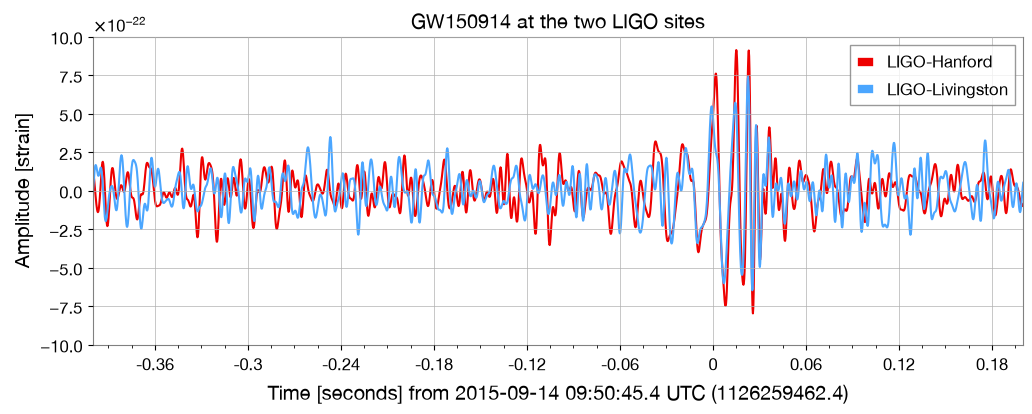

In [5]:
from gwosc.datasets import event_gps
from gwpy.timeseries import TimeSeries
from gwpy.signal import filter_design
from gwpy.plot import Plot
t0 = event_gps("GW150914")
hdata = TimeSeries.fetch_open_data("H1", t0 - 16, t0 + 16)
ldata = TimeSeries.fetch_open_data("L1", t0 - 16, t0 + 16)
bp = filter_design.bandpass(50, 250, hdata.sample_rate)
notches = [filter_design.notch(f, hdata.sample_rate) for f in (60, 120, 180)]
zpk = filter_design.concatenate_zpks(bp, *notches)
hfilt = hdata.filter(zpk, filtfilt=True)
lfilt = ldata.filter(zpk, filtfilt=True)
lfilt.shift("6.9ms")
lfilt *= -1
plot = Plot(figsize=(12, 4))
ax = plot.gca()
ax.plot(hfilt, label="LIGO-Hanford", color="gwpy:ligo-hanford")
ax.plot(lfilt, label="LIGO-Livingston", color="gwpy:ligo-livingston")
ax.set(xlim=(t0 - 0.4, t0 + 0.2), ylim=(-1e-21, 1e-21),
       title="GW150914 at the two LIGO sites", ylabel="Amplitude [strain]")
ax.set_xscale("seconds", epoch=t0)
ax.legend()
plot;

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">נבחן את שתי הסדרות המבוקשות ואת תיקון ההשוואה המפורש לפני פירוש הגרף.</p>
</div>

In [6]:
{"event_gps": t0, "requested_seconds": 32,
 "H1_samples": len(hdata), "L1_samples": len(ldata),
 "sample_rate_Hz": hdata.sample_rate.value,
 "L1_comparison_transform": "shift +6.9 ms, multiply by -1"}

{'event_gps': 1126259462.4,
 'requested_seconds': 32,
 'H1_samples': 131072,
 'L1_samples': 131072,
 'sample_rate_Hz': np.float64(4096.0),
 'L1_comparison_transform': 'shift +6.9 ms, multiply by -1'}